## Tutorial: triangular meshes in `triangulax`

This short tutorial gives a practical overview of the main mesh data structures in `triangulax`. We will cover:

1. loading triangular meshes as lists of triangles with `TriMesh`,
2. visualizing meshes in 2D and, optionally, in 3D with `meshplot`,
3. why `HeMesh` is useful, how the array-based half-edge representation works, and how edge flips work,
4. a simple geometry-processing example based on the Voronoi dual.

The aim is not to give a full introduction to geometry processing, but to show the basic workflow for using the library.

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

jax.config.update("jax_enable_x64", True)

try:
    import meshplot
except ImportError:
    meshplot = None

from triangulax.triangular import TriMesh
from triangulax.mesh import HeMesh, GeomMesh, label_plot, cellplot
from triangulax.topology import flip_edge
from triangulax import trigonometry as trig
from triangulax import geometry as geom

### 1. `TriMesh`: a mesh as vertices and triangles

At the most basic level, a triangular mesh is just:

- a vertex array of shape `(n_vertices, dim)`, and
- a face array of shape `(n_faces, 3)`, where each row stores the three vertex indices of a triangle.

`TriMesh` is the light-weight container for this representation. It is useful for loading and saving meshes, plotting them, and interfacing with external geometry-processing tools.

In [5]:
disk = TriMesh.read_obj("tutorial_meshes/disk.obj")
torus = TriMesh.read_obj("tutorial_meshes/torus.obj", dim=3)

manual_mesh = TriMesh(
    vertices=jnp.array([[0.0, 0.0],
                        [1.0, 0.0],
                        [1.0, 1.0],
                        [0.0, 1.0]]),
    faces=jnp.array([[0, 1, 2],
                     [0, 2, 3]])
)

print(f"disk mesh: {disk.vertices.shape[0]} vertices, {disk.faces.shape[0]} faces")
print(f"torus mesh: {torus.vertices.shape[0]} vertices, {torus.faces.shape[0]} faces")
print("manual mesh faces:")
print(np.array(manual_mesh.faces))

  o flat_tri_ecmc


disk mesh: 131 vertices, 224 faces
torus mesh: 576 vertices, 1152 faces
manual mesh faces:
[[0 1 2]
 [0 2 3]]


  o Torus


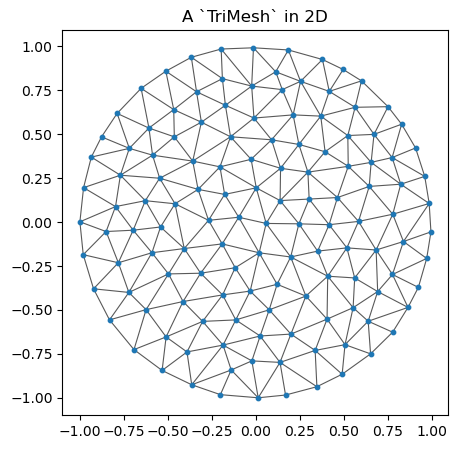

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.triplot(np.array(disk.vertices[:, 0]), np.array(disk.vertices[:, 1]), np.array(disk.faces),
           color="0.35", lw=0.8)
ax.scatter(*np.array(disk.vertices).T, s=10, color="tab:blue")
ax.set_aspect("equal")
ax.set_title("A `TriMesh` in 2D")
plt.show()

### 2. Visualizing meshes in 2D and 3D

For planar meshes, `matplotlib` is usually enough. For a 3D mesh, `meshplot` is convenient for quick interactive inspection. The tutorial keeps this optional: if `meshplot` is not installed, the rest still runs.

In [4]:
if meshplot is None:
    print("`meshplot` is not installed, so skipping the 3D plot.")
else:
    meshplot.plot(np.array(torus.vertices), np.array(torus.faces),
                  shading={"wireframe": False})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

### 3. Why use a half-edge mesh?

A list of triangles is enough to store a mesh, but many geometry-processing operations need adjacency information: for example, finding the triangles around a vertex, constructing a dual mesh, or performing local topology changes.

`triangulax` is based on the half-edge data structure (for a longer explanation, see [Jerry Yin's notes](https://jerryyin.info/geometry-processing-algorithms/half-edge/)). In brief, you can think of a mesh as comprising vertices, edges, and faces, together with the information how these elements are connected. It turns out to be very convenient to "split" each edge into two "twin" half-edges with opposite orientation:

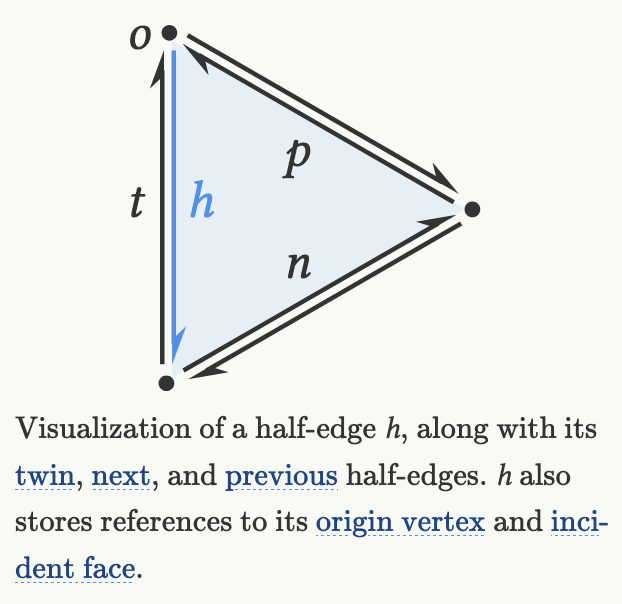

`triangulax` stores the half-edge connectivity in the array-based `HeMesh` data structure. The most important arrays are:

- `incident`: one outgoing half-edge per vertex,
- `orig` and `dest`: the origin and destination of each half-edge,
- `nxt` and `prv`: the next and previous half-edge inside a face,
- `twin`: the half-edge on the same edge with opposite orientation,
- `heface` and `face_incident`: the face attached to a half-edge, and one half-edge attached to a face.

The entries in the above arrays are _indices_ of vertices, half-edges, and faces.

In [10]:
hemesh = HeMesh.from_triangles(manual_mesh.vertices.shape[0], manual_mesh.faces)

print("faces recovered from `HeMesh`:")
print(np.array(hemesh.faces))
print()
print("incident:", np.array(hemesh.incident))
print("orig:", np.array(hemesh.orig))
print("dest:", np.array(hemesh.dest))
print("twin:", np.array(hemesh.twin))
print("nxt:", np.array(hemesh.nxt))
print("prv:", np.array(hemesh.prv))
print("heface:", np.array(hemesh.heface))
print("face_incident:", np.array(hemesh.face_incident))

print()
print("half-edges around vertex 0:", np.array(hemesh.iterate_around_vertex(0)))

faces recovered from `HeMesh`:
[[0 1 2]
 [0 2 3]]

incident: [0 3 4 7]
orig: [0 0 0 1 2 1 2 3 2 3]
dest: [1 2 3 2 3 0 0 0 1 2]
twin: [5 6 7 8 9 0 1 2 3 4]
nxt: [3 4 9 6 7 2 0 1 5 8]
prv: [6 7 5 0 1 8 3 4 9 2]
heface: [ 0  1 -1  0  1 -1  0  1 -1 -1]
face_incident: [0 1]

half-edges around vertex 0: [0 1 2]


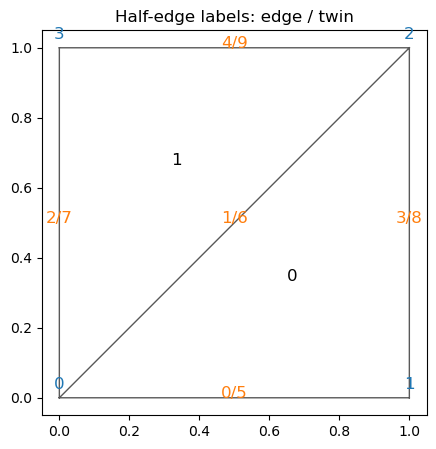

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.triplot(np.array(manual_mesh.vertices[:, 0]), np.array(manual_mesh.vertices[:, 1]), np.array(hemesh.faces),
           color="0.35", lw=1.0)
label_plot(manual_mesh.vertices, hemesh.faces, hemesh=hemesh, ax=ax, fontsize=12)
ax.set_aspect("equal")
ax.set_title("Half-edge labels: edge / twin")
plt.show()

An important advantage of the half-edge representation is that local connectivity changes are easy to express. In tissue models, this corresponds to a T1 transition; in geometry processing it is the standard **edge flip**.

flipping interior edge 1
faces before flip:
[[0 1 2]
 [0 2 3]]
faces after flip:
[[1 2 3]
 [3 0 1]]


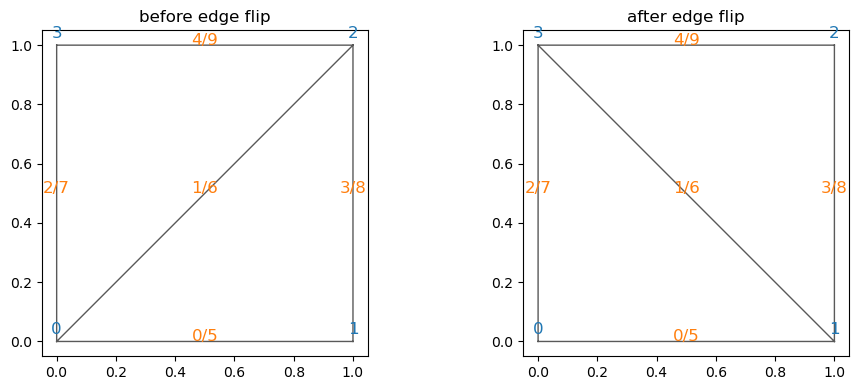

In [12]:
edge_to_flip = int(np.array(jnp.where((~hemesh.is_bdry_edge) & hemesh.is_unique)[0])[0])
assert np.array(hemesh.heface)[edge_to_flip] != -1
assert np.array(hemesh.heface)[np.array(hemesh.twin)[edge_to_flip]] != -1

flipped_hemesh = flip_edge(hemesh, edge_to_flip)

print(f"flipping interior edge {edge_to_flip}")
print("faces before flip:")
print(np.array(hemesh.faces))
print("faces after flip:")
print(np.array(flipped_hemesh.faces))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, current_hemesh, title in zip(
    axes,
    [hemesh, flipped_hemesh],
    ["before edge flip", "after edge flip"],
):
    ax.triplot(np.array(manual_mesh.vertices[:, 0]), np.array(manual_mesh.vertices[:, 1]),
               np.array(current_hemesh.faces), color="0.35", lw=1.0)
    label_plot(manual_mesh.vertices, current_hemesh.faces, hemesh=current_hemesh,
               ax=ax, face_labels=False, fontsize=12)
    ax.set_aspect("equal")
    ax.set_title(title)
plt.tight_layout()
plt.show()

### 4. Geometry processing example: the Voronoi dual

A common construction in `triangulax` is the dual cell complex of a triangulation. For a planar triangular mesh, the Voronoi dual is built from the circumcenters of the triangles. Once we have the half-edge mesh, we can compute dual quantities such as Voronoi face positions and Voronoi cell areas.

In [15]:
# load mesh

disk_hemesh = HeMesh.from_triangles(disk.vertices.shape[0], disk.faces)

In [ ]:
# compute Voronoi face positions and areas using the geometry module

voronoi_face_positions = geom.get_voronoi_face_positions(disk.vertices, disk_hemesh)
voronoi_areas = geom.get_voronoi_areas(disk.vertices, disk_hemesh)
disk_geommesh = GeomMesh(*disk_hemesh.n_items, vertices=disk.vertices, face_positions=voronoi_face_positions)

In [26]:
# under the hood, the geometry module uses the half-edge mesh datastructure to "look up" all the mesh
# elements required to compute the circumcenters, like so:

disk_hemesh.face_incident # the 1st half-edge in every triangular face
disk_hemesh.nxt[disk_hemesh.face_incident] # the 2nd half-edge is obtained by looking up the "next" half-edge in the same face
disk_hemesh.orig[disk_hemesh.face_incident] # the origin vertex of that half-edge, i.e. the 1st vertex of the triangular face

a, b, c = [disk_hemesh.orig[disk_hemesh.face_incident], # the 3 verices of the every triangle
           disk_hemesh.orig[disk_hemesh.nxt[disk_hemesh.face_incident]], 
           disk_hemesh.orig[disk_hemesh.nxt[disk_hemesh.nxt[disk_hemesh.face_incident]]]]

# using the indices a, b, c, we can look up the corner positions for each triangle and compute the circumcenter
# using the trigonometry module. The jax.vmap function vectorizes trig.get_circumcenter so we can apply it
# # to all triangles at once. 
circumcenters = jax.vmap(trig.get_circumcenter)(disk_geommesh.vertices[a], disk_geommesh.vertices[b], disk_geommesh.vertices[c])
print("# circumcenters computed:", circumcenters.shape, "# faces in mesh:", disk_hemesh.n_faces)



# circumcenters computed: (224, 2) # faces in mesh: 224


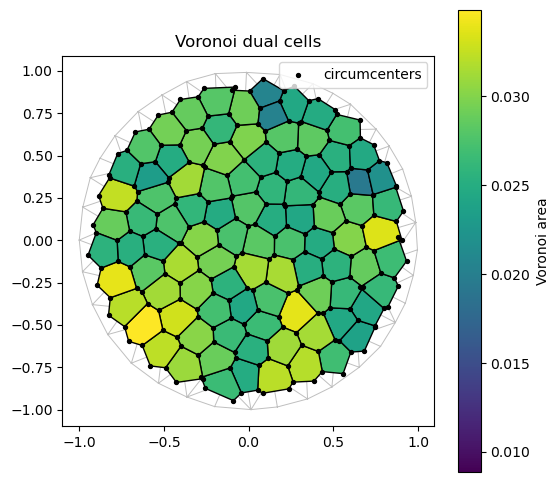

first 10 Voronoi areas:
[0.01225838 0.02388455 0.02437098 0.02871522 0.0299997  0.02824959
 0.01938853 0.02515057 0.02536109 0.01070723]


In [17]:
voronoi_areas_np = np.array(voronoi_areas)
norm = mcolors.Normalize(vmin=float(voronoi_areas_np.min()),
                         vmax=float(voronoi_areas_np.max()))
cell_colors = plt.cm.viridis(norm(voronoi_areas_np))

fig, ax = plt.subplots(figsize=(6, 6))
ax.triplot(np.array(disk.vertices[:, 0]), np.array(disk.vertices[:, 1]), np.array(disk_hemesh.faces),
           color="0.75", lw=0.7)
patches = cellplot(disk_hemesh, disk_geommesh.face_positions,
                   cell_colors=cell_colors,
                   mpl_polygon_kwargs={"lw": 1.0, "ec": "k"})
ax.add_collection(patches)
ax.scatter(*np.array(disk_geommesh.face_positions).T, s=8, color="k", label="circumcenters")
ax.set_aspect("equal")
ax.set_title("Voronoi dual cells")
ax.legend(loc="upper right")
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
             ax=ax, label="Voronoi area")
plt.show()

print("first 10 Voronoi areas:")
print(voronoi_areas_np[:10])

### Further reading

- For the half-edge data structure itself, Jerry Yin's notes are an excellent starting point: <https://jerryyin.info/geometry-processing-algorithms/half-edge/>.
- For broader geometry-processing background and many standard constructions, see the [libigl tutorials](https://libigl.github.io/tutorial/).
- Within `triangulax`, the more detailed source notebooks are the half-edge and geometry notebooks in the `src/` folder.